CONCLUSIÓN DEL ANALISTA:
Por cada hora extra de estudio, el alumno compra 0.52 tazas más.
Consumo base (aunque no estudie): 0.42 tazas.


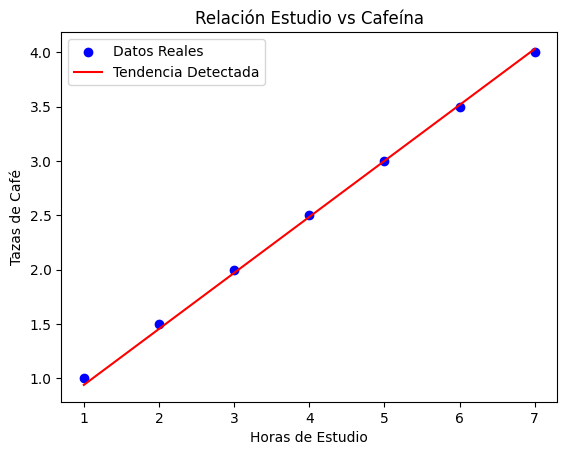

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. EL MERCADO (Observaciones de Campo) ---
# X = Horas de estudio en la biblioteca
# y = Tazas de café consumidas

# Datos observados (Realidad)
horas_estudio = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0]])
tazas_cafe =    torch.tensor([[1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0]])

# Visualizamos el mercado
plt.scatter(horas_estudio, tazas_cafe, color='blue', label='Datos Reales')

# --- 2. LA AGENCIA (Setup) ---
modelo = nn.Linear(1, 1) # Un analista lineal
criterion = nn.MSELoss() # El auditor
optimizer = optim.SGD(modelo.parameters(), lr=0.01) # El gerente

# --- 3. ENTRENAMIENTO ---
for i in range(500):
    y_pred = modelo(horas_estudio)
    loss = criterion(y_pred, tazas_cafe)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- 4. RESULTADOS ---
w = modelo.weight.item()
b = modelo.bias.item()

print(f"CONCLUSIÓN DEL ANALISTA:")
print(f"Por cada hora extra de estudio, el alumno compra {w:.2f} tazas más.")
print(f"Consumo base (aunque no estudie): {b:.2f} tazas.")

# --- 5. VISUALIZACIÓN ---
prediccion_linea = modelo(horas_estudio).detach().numpy()
plt.plot(horas_estudio, prediccion_linea, color='red', label='Tendencia Detectada')
plt.title("Relación Estudio vs Cafeína")
plt.xlabel("Horas de Estudio")
plt.ylabel("Tazas de Café")
plt.legend()
plt.show()

Entrenando analista...
¡Entrenamiento terminado!
Fórmula descubierta: Ventas = 10.31 * Temperatura + -0.80


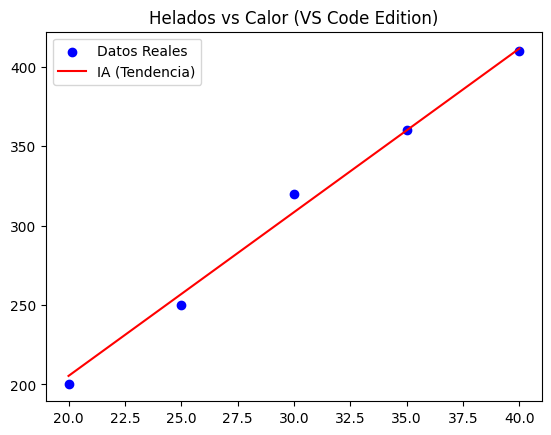

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. DATOS (La Realidad) ---
# Temperatura (X) vs Ventas (y)
temperatura = torch.tensor([[20.0], [25.0], [30.0], [35.0], [40.0]])
ventas_reales = torch.tensor([[200.0], [250.0], [320.0], [360.0], [410.0]])

# --- 2. MODELO (El Analista) ---
modelo = nn.Linear(1, 1) # Una neurona simple (y = wx + b)

# --- 3. ENTRENAMIENTO (El Bootcamp) ---
criterion = nn.MSELoss()
optimizer = optim.SGD(modelo.parameters(), lr=0.001)

print("Entrenando analista...")
for i in range(1000):
    prediccion = modelo(temperatura)
    loss = criterion(prediccion, ventas_reales)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- 4. RESULTADOS VISUALES ---
print("¡Entrenamiento terminado!")
w = modelo.weight.item()
b = modelo.bias.item()
print(f"Fórmula descubierta: Ventas = {w:.2f} * Temperatura + {b:.2f}")

# Graficamos
prediccion_final = modelo(temperatura).detach().numpy()
plt.scatter(temperatura, ventas_reales, color='blue', label='Datos Reales')
plt.plot(temperatura, prediccion_final, color='red', label='IA (Tendencia)')
plt.title("Helados vs Calor (VS Code Edition)")
plt.legend()
plt.show()

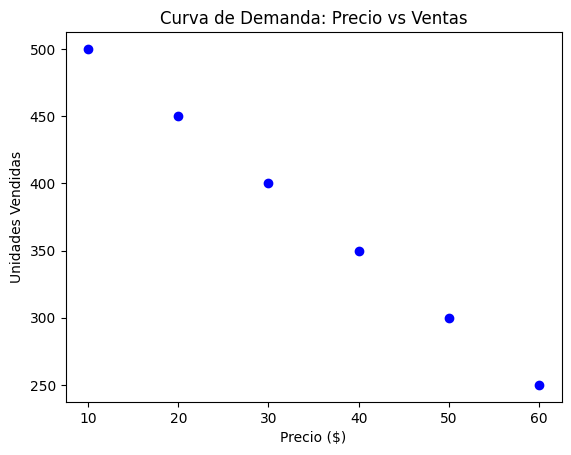

--- Entrenando para entender la sensibilidad de precio ---
Vuelta 0: Error = 135279.22
Vuelta 500: Error = 55805.80
Vuelta 1000: Error = 53701.23
Vuelta 1500: Error = 51676.04

--- INFORME FINAL DE PRICING ---
Sensibilidad al Precio (w): 6.74
Demanda Máxima Teórica (b): 41.49

--- INTERPRETACIÓN ---
1. Si el producto fuera GRATIS ($0), te pedirían aprox 41 unidades.
2. IMPORTANTE: El signo de 'w' es negativo (6.74).
   Significa que por cada PESO que subes el precio, pierdes -6.74 clientes.


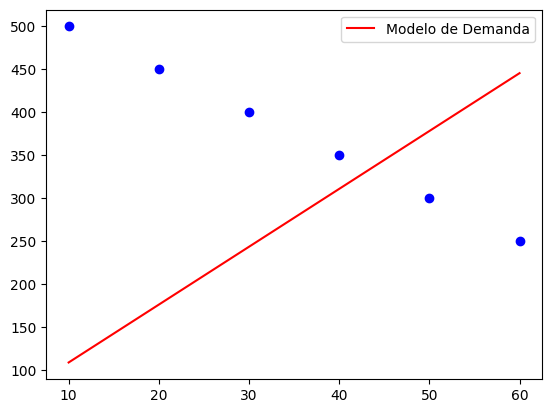

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. EL MERCADO (Datos Simulados) ---
# Hipótesis: La gente ama lo barato.
# X = Precio del Filtro (Pesos)
# y = Cantidad de Filtros Vendidos al día

# Fíjate en los datos: Entre MÁS alto el precio (X), MENOS vendemos (y)
precio = torch.tensor([[10.0], [20.0], [30.0], [40.0], [50.0], [60.0]])
ventas = torch.tensor([[500.0], [450.0], [400.0], [350.0], [300.0], [250.0]])

# Visualizamos la realidad antes de entrenar
plt.scatter(precio, ventas, color='blue', label='Datos Reales')
plt.title("Curva de Demanda: Precio vs Ventas")
plt.xlabel("Precio ($)")
plt.ylabel("Unidades Vendidas")
plt.show()

# --- 2. LA AGENCIA (El Modelo) ---
# Contratamos al Analista Lineal de siempre.
# Él no sabe que la relación es negativa, tiene que descubrirlo solo.
modelo = nn.Linear(1, 1) 

# --- 3. REGLAS DE NEGOCIO (Loss y Optimizer) ---
criterion = nn.MSELoss() 
# Usamos un Learning Rate pequeño (0.0001) para que el ajuste sea suave
optimizer = optim.SGD(modelo.parameters(), lr=0.0001)

# --- 4. ENTRENAMIENTO (El Bootcamp) ---
print("--- Entrenando para entender la sensibilidad de precio ---")

for epoch in range(2000): # Le damos 2000 vueltas para que afine bien
    
    # A. Predicción: El modelo ve el precio e intenta adivinar la venta
    y_pred = modelo(precio)
    
    # B. Auditoría: Comparamos predicción con venta real
    loss = criterion(y_pred, ventas)
    
    # C. Ajuste (Backpropagation)
    optimizer.zero_grad() # Limpiamos culpas pasadas
    loss.backward()       # Calculamos gradientes (¿subir o bajar w?)
    optimizer.step()      # Aplicamos el cambio

    if epoch % 500 == 0:
        print(f"Vuelta {epoch}: Error = {loss.item():.2f}")

# --- 5. RESULTADOS ESTRATÉGICOS ---
print("\n--- INFORME FINAL DE PRICING ---")

# Extraemos los valores de la mente de la IA
w = modelo.weight.item()
b = modelo.bias.item()

print(f"Sensibilidad al Precio (w): {w:.2f}")
print(f"Demanda Máxima Teórica (b): {b:.2f}")

# --- 6. TRADUCCIÓN A LENGUAJE HUMANO ---
print("\n--- INTERPRETACIÓN ---")
print(f"1. Si el producto fuera GRATIS ($0), te pedirían aprox {b:.0f} unidades.")
print(f"2. IMPORTANTE: El signo de 'w' es negativo ({w:.2f}).")
print(f"   Significa que por cada PESO que subes el precio, pierdes {-w:.2f} clientes.")

# Graficamos la línea de tendencia
prediccion_final = modelo(precio).detach().numpy()
plt.scatter(precio, ventas, color='blue')
plt.plot(precio, prediccion_final, color='red', label='Modelo de Demanda')
plt.legend()
plt.show()

In [5]:
# Simulador de Venta Base
venta_base = 100 
grados_centigrados = 25 # x

# RETO: Pon un peso absurdamente alto (ej. 999999) 
# o uno muy pequeño (ej. 0.0001)
peso_clima = 10# <--- ¡PON AQUÍ TU NÚMERO "LOCO"!

venta_proyectada = (peso_clima * grados_centigrados) + venta_base

print(f"Con ese peso, la IA dice que venderemos: {venta_proyectada} unidades")

Con ese peso, la IA dice que venderemos: 350 unidades


In [6]:
# Resultados de nuestro análisis de mercado
pesos_modelo = {
    "Precio": -850.0,      # w1
    "Publicidad": 120.5,   # w2
    "Promociones": 450.0,  # w3
    "Escasez_Agua": 950.0  # w4
}

# Queremos encontrar el driver con el impacto más FUERTE (sin importar el signo)
# PISTA: Usamos max() y le decimos que mire el valor absoluto
driver_principal = max(pesos_modelo, key=lambda k: abs(pesos_modelo[k]))

# RETO: ¿Qué valor crees que imprimirá la siguiente línea?
# Escribe el nombre del driver que crees que ganará:
ganador_esperado = "________" # <--- ¡Pon el nombre aquí!

print(f"El driver que más mueve la aguja es: {driver_principal}")

El driver que más mueve la aguja es: Escasez_Agua


In [9]:
drivers_estudio = {
    "Precio": -850,
    "Campaña_Influencers": 12, # Muy bajito
    "Escasez_Agua": 950,
    "Color_del_Logo": 0.5      # Casi cero
}

drivers_relevantes = []

for nombre, peso in drivers_estudio.items():
    # RETO: Si el valor absoluto del peso es > 100, es relevante
    # Pista: usa abs(peso)
    if peso > 100:
        drivers_relevantes.append(nombre)

print(f"Joel, para la junta solo presenta estos drivers: {drivers_relevantes}")

Joel, para la junta solo presenta estos drivers: ['Escasez_Agua']


In [10]:
# Joel, este es tu resumen de drivers post-auditoría
analisis_final = {
    "Precio_Premium": -900,
    "Inversion_TV": 0,          # Lasso ya le dio cuello
    "Escasez_Agua": 950,
    "Promos_Buen_Fin": 150
}

# Filtramos los que sí mueven la aguja
ganadores = [name for name, w in analisis_final.items() if abs(w) > 100]

print(f"Partner, los drivers para la estrategia 2024 son: {ganadores}")

Partner, los drivers para la estrategia 2024 son: ['Precio_Premium', 'Escasez_Agua', 'Promos_Buen_Fin']


In [12]:
venta_real = 120
venta_predicha = 100

# RETO: Calcula el error absoluto y divídelo entre la venta real
# para obtener el porcentaje de desfase.
diferencia = abs(venta_real - venta_predicha)
porcentaje_error = (diferencia / venta_real) * 100

if porcentaje_error < 20:
    print(f"¡Bien, Joel! El error es de {porcentaje_error}%. El cliente estará feliz.")
else:
    print(f"Ojo, Partner. {porcentaje_error}% de error ya es mucho ruido.")

¡Bien, Joel! El error es de 16.666666666666664%. El cliente estará feliz.


In [13]:
error_entrenamiento = 5.0 # El modelo ya se sabe estos datos
error_prueba_real = 45.0  # Datos nuevos (out-of-sample)

# RETO: Completa la lógica de diagnóstico
# Si el error en prueba es MUCHO mayor al de entrenamiento, hay OVERFITTING
if error_prueba_real > (error_entrenamiento * 3):
    diagnostico = "¡Cuidado! El modelo está overfited" # <--- ¿Qué palabra pondrías?
else:
    diagnostico = "El modelo generaliza bien. ¡Dale luz verde!"

print(f"Resultado: {diagnostico}")

Resultado: ¡Cuidado! El modelo está overfited


In [14]:
import numpy as np

reales = np.array([12, 13, 5, 15])

# Modelo A (El de tu Sheets: Siempre 10)
pred_A = np.array([10, 10, 10, 10])

# Modelo B (Más dinámico: Sigue un poco más la tendencia)
pred_B = np.array([11, 12, 7, 14])

def calcular_mape(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred) / y_real) * 100

mape_A = calcular_mape(reales, pred_A)
mape_B = calcular_mape(reales, pred_B)

# RETO: ¿Cuál crees que será el MAPE del Modelo B? 
# ¿Bajará de la zona roja (>40%) a la zona amarilla?
print(f"MAPE Modelo A: {mape_A:.2f}%")
print(f"MAPE Modelo B: {mape_B:.2f}%")

MAPE Modelo A: 43.27%
MAPE Modelo B: 15.67%


In [15]:
# Escenarios de negocio
error_grande_es_muy_caro = True
comparar_paises_diferentes = False

# Lógica de decisión
if comparar_paises_diferentes:
    metrica_recomendada = "MAPE"
elif error_grande_es_muy_caro:
    # RETO: ¿Cuál es la métrica que castiga los errores grandes?
    metrica_recomendada = "rmse" 
else:
    metrica_recomendada = "MAE"

print(f"Partner, para este caso en Rotoplas usaremos: {metrica_recomendada}")

Partner, para este caso en Rotoplas usaremos: rmse
